In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from pathlib import Path
import os

In [14]:
def get_root_path() -> Path:
    cwd = os.getcwd()
    cwd_path = Path(cwd)
    return cwd_path.parent.parent

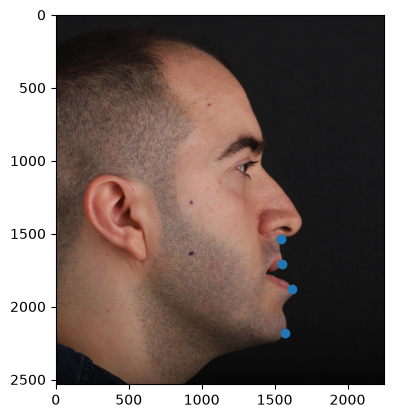

In [30]:
n = 15

manifest_path = "/home/furkan/projects/mebar-orthognatic/data/processed/manifest.csv"
manifest_df = pd.read_csv(manifest_path)

points = ["subnasale", "upper_lip_anterior", "lower_lip_anterior", "pogonion"]
points = [[f"{point}_x", f"{point}_y"] for point in points]
points = np.array(points).flatten().tolist()

keypoints_coords = manifest_df.iloc[n][points]
keypoints_coords = np.asarray(keypoints_coords, dtype=float).reshape(-1, 2)

image_path = get_root_path() / manifest_df.iloc[n]["image_path"]
image = io.imread(image_path)

plt.imshow(image)
plt.scatter(x=keypoints_coords[:,0], y=keypoints_coords[:,1])

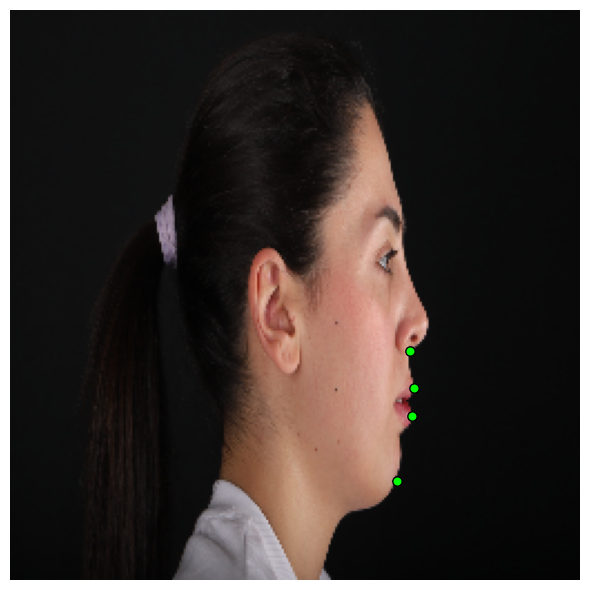

In [5]:
from transforms import train_transform
import torch
import numpy as np
import matplotlib.pyplot as plt
from dataset import Heatmap2D_Dataset
import os
import pandas as pd

def smart_imshow(image, points=None, title=None):
    """
    Auto-detects tensor/numpy, channel ordering (C, H, W vs H, W, C),
    and normalization state (standard [0..1]/[0..255] vs ImageNet normalized).
    """
    # 1. Convert to NumPy
    if isinstance(image, torch.Tensor):
        img = image.detach().cpu().numpy()
    else:
        img = np.array(image, copy=True)

    # 2. Fix Channel Ordering: (C, H, W) -> (H, W, C)
    if img.ndim == 3 and img.shape[0] in [1, 3, 4]:
        img = np.transpose(img, (1, 2, 0))

    # Single-channel grayscale fix
    if img.ndim == 3 and img.shape[2] == 1:
        img = img.squeeze(axis=2)

    # 3. Detect and Reverse Normalization
    # If values are below 0 or around ImageNet distribution
    if img.min() < 0.0 or (img.dtype in [np.float32, np.float64] and img.max() > 1.0 and img.max() <= 3.0):
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        if img.ndim == 3 and img.shape[2] == 3:
            img = (img * std) + mean
        else:
            # Fallback min-max scaling for single channel / unknown distribution
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # If it's standard 0-255 uint8 range in float format
    elif img.max() > 1.0:
        img = img / 255.0

    # 4. Safe Clip
    img = np.clip(img, 0.0, 1.0)

    # 5. Plotting
    plt.figure(figsize=(6, 6))
    if img.ndim == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img)

    if points is not None:
        if isinstance(points, torch.Tensor):
            pts = points.detach().cpu().numpy()
        else:
            pts = np.asarray(points)
        plt.scatter(pts[:, 0], pts[:, 1], c='lime', edgecolors='black', s=45, marker='o')

    if title:
        plt.title(title)

    plt.axis('off')
    plt.tight_layout()
    plt.show()

os.chdir("/home/furkan/projects/mebar-orthognatic")

manifest_df = pd.read_csv("/home/furkan/projects/mebar-orthognatic/data/processed/manifest.csv")

dataset = Heatmap2D_Dataset(
    df=manifest_df,
    root_path="/home/furkan/projects/mebar-orthognatic",
    transform=train_transform
)

n = 2

sample = dataset[n]
smart_imshow(sample.image, sample.points)